## Import Necessary Modules

In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Resizing, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, UpSampling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import KLDivergence, CategoricalCrossentropy
import matplotlib.pyplot as plt

## Plotting function

In [9]:

def plot_metrics(history, title):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

## Small CNN student Model from scratch


--- EXPERIMENT 1: TRAINING STUDENT (BASELINE) ---



Model: "Simple_Student_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,051,018 (4.01 MB)

 Trainable params: 1,050,954 (4.01 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3621 - loss: 1.8652 - val_accuracy: 0.4777 - val_loss: 1.6469
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5428 - loss: 1.2805 - val_accuracy: 0.5891 - val_loss: 1.2108
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6031 - loss: 1.1236 - val_accuracy: 0.6122 - val_loss: 1.1155
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6444 - loss: 1.0010 - val_accuracy: 0.5909 - val_loss: 1.1720
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6702 - loss: 0.9282 - val_accuracy: 0.5792 - val_loss: 1.2429
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6957 - loss: 0.8363 - val_accuracy: 0.6016 - val_loss: 1.2055
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7172 - loss: 0.7889 - val_accuracy: 0.6325 - val_loss: 1.0764
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7393 - loss: 0.7263 - val_accuracy: 0

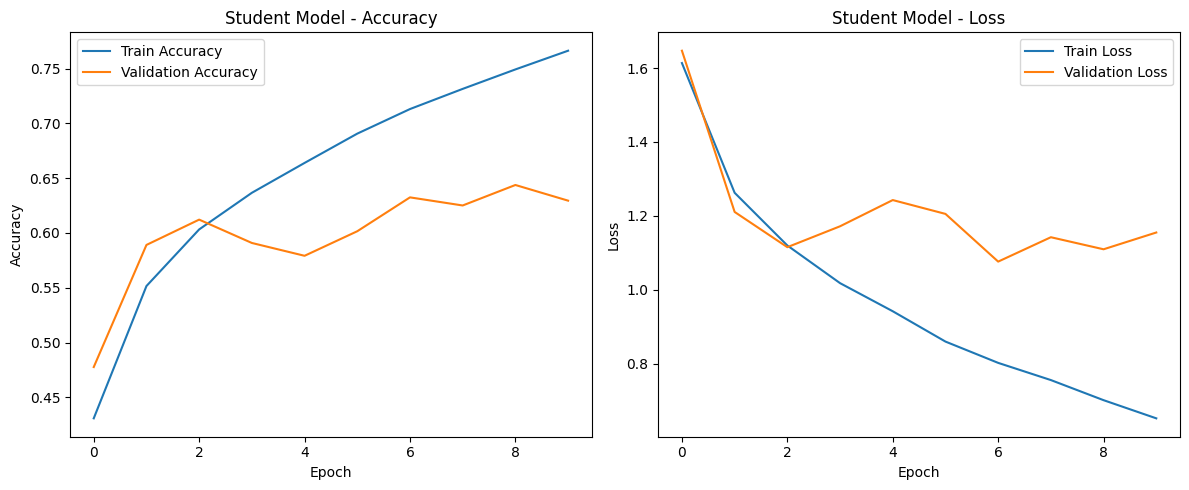

Baseline Student Test Accuracy: 0.6245


In [10]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train.astype('float32') / 255.0, x_test.astype('float32') / 255.0
y_train_cat, y_test_cat = to_categorical(y_train, 10), to_categorical(y_test, 10)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# STUDENT MODEL ARCHITECTURE
def create_student_model(input_shape=(32, 32, 3), num_classes=10):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs, name="Simple_Student_CNN")

# Student model training and evalution
print("\n--- EXPERIMENT 1: TRAINING STUDENT (BASELINE) ---\n")

results = {}
histories = {}

student_baseline = create_student_model()
student_baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
student_baseline.summary()

history_student_baseline = student_baseline.fit(
    x_train, y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

plot_metrics(history_student_baseline, "Student Model")

# Evaluate and store results
loss, acc = student_baseline.evaluate(x_test, y_test_cat, verbose=0)
results["Student_Baseline"] = {"Test Loss": loss, "Test Accuracy": acc}
histories["Student_Baseline"] = history_student_baseline
print(f"Baseline Student Test Accuracy: {acc:.4f}")

## TEACHER MODEL ARCHITECTURE

In [11]:
def create_teacher_model(base_model_class, model_name, layers_to_unfreeze=10):
    base_model = base_model_class(include_top=False, weights='imagenet', input_shape=None)
    base_model.trainable = False
    for layer in base_model.layers[-layers_to_unfreeze:]:
        layer.trainable = True

    inputs = Input(shape=(32, 32, 3))
    x = Resizing(48, 48)(inputs)
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs, outputs, name=model_name)
    return model

# Traning and evaluating Teacher1 Model


--- Training Teacher 1: VGG16 ---
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 114ms/step - accuracy: 0.5411 - loss: 1.3266 - val_accuracy: 0.7896 - val_loss: 0.6063
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.8207 - loss: 0.5461 - val_accuracy: 0.8322 - val_loss: 0.4926
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.8785 - loss: 0.3643 - val_accuracy: 0.8522 - val_loss: 0.4417
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.9250 - loss: 0.2290 - val_accuracy: 0.8449 - val_loss: 0.4763
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.9466 - loss: 0.1602 - val_accuracy: 0.8462 - val_loss: 0.5334
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 98ms/step - accuracy: 0.9651 - loss: 0.1058 - val_accuracy: 0.8598 - val_loss: 0.4761
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.9766 - loss: 0.0712 - val_accuracy: 0.8628 - val_loss: 0.5511
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/ste

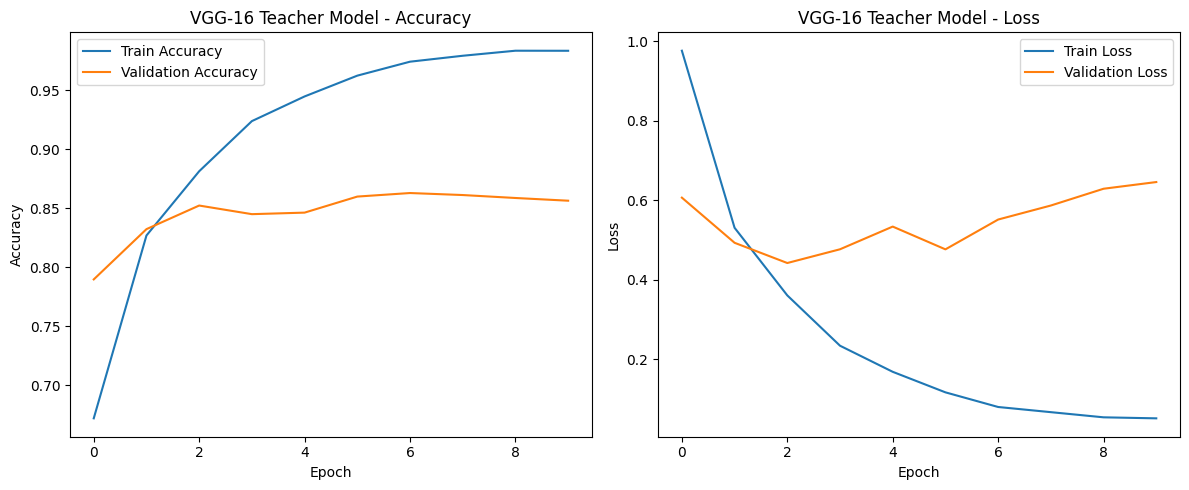

VGG16 Teacher Test Accuracy: 0.8522


In [12]:
# Train VGG16 Teacher
print("\n--- Training Teacher 1: VGG16 ---")
teacher_vgg16 = create_teacher_model(VGG16, "Teacher_VGG16")
teacher_vgg16.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_teacher_vgg16 = teacher_vgg16.fit(x_train, y_train_cat, validation_split=0.2, epochs=10, batch_size=128, verbose=1)

plot_metrics(history_teacher_vgg16, "VGG-16 Teacher Model")

loss, acc = teacher_vgg16.evaluate(x_test, y_test_cat, verbose=0)
results["Teacher_VGG16"] = {"Test Loss": loss, "Test Accuracy": acc}
histories["Teacher_VGG16"] = history_teacher_vgg16
print(f"VGG16 Teacher Test Accuracy: {acc:.4f}")


--- Training Teacher 3: VGG19 ---
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 154ms/step - accuracy: 0.4653 - loss: 1.5088 - val_accuracy: 0.7304 - val_loss: 0.7781
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.7755 - loss: 0.6719 - val_accuracy: 0.8099 - val_loss: 0.5563
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - accuracy: 0.8503 - loss: 0.4574 - val_accuracy: 0.8292 - val_loss: 0.5088
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - accuracy: 0.8990 - loss: 0.3138 - val_accuracy: 0.8262 - val_loss: 0.5407
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 122ms/step - accuracy: 0.9237 - loss: 0.2317 - val_accuracy: 0.8454 - val_loss: 0.5068
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 122ms/step - accuracy: 0.9520 - loss: 0.1488 - val_accuracy: 0.8383 - val_loss: 0.5889
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9614 - loss: 0.1205 - val_accuracy: 0.8128 - val_loss: 0.75

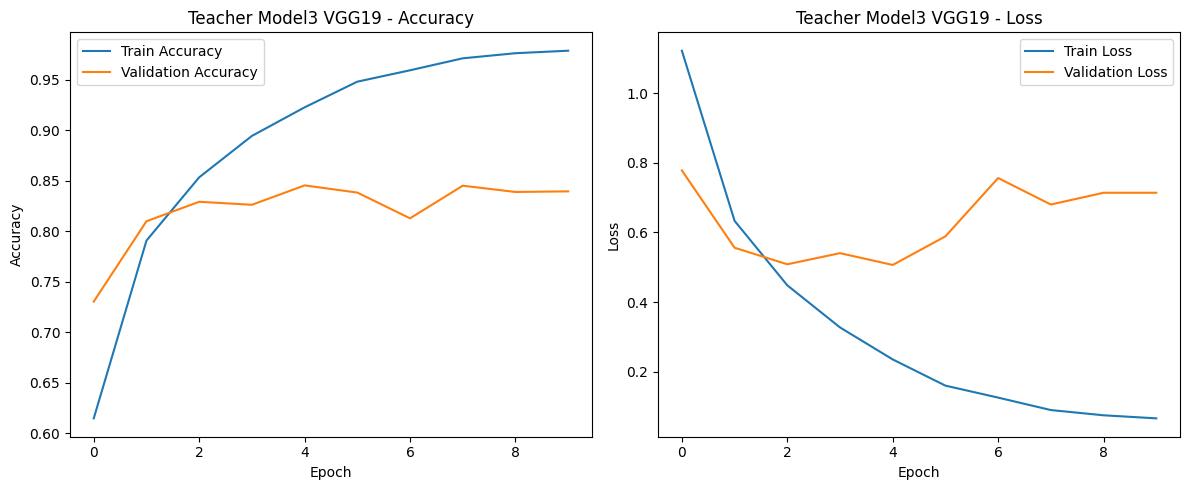

VGG19 Teacher Test Accuracy: 0.8267


In [16]:
from tensorflow.keras.applications import VGG19

# Train VGG19 Teacher
print("\n--- Training Teacher 3: VGG19 ---")
teacher_vgg19 = create_teacher_model(VGG19, "Teacher_VGG19")
teacher_vgg19.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

history_teacher_vgg19 = teacher_vgg19.fit(
    x_train, y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

plot_metrics(history_teacher_vgg19, "Teacher Model3 VGG19")

# Evaluate
loss, acc = teacher_vgg19.evaluate(x_test, y_test_cat, verbose=0)
results["Teacher_VGG19"] = {"Test Loss": loss, "Test Accuracy": acc}
histories["Teacher_VGG19"] = history_teacher_vgg19
print(f"VGG19 Teacher Test Accuracy: {acc:.4f}")


## Knowledge distillation Function

In [17]:
class Distiller(Model):
    def __init__(self, student, teachers):
        super().__init__()
        self.student = student
        self.teachers = teachers if isinstance(teachers, list) else [teachers]

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn, alpha=0.1, temperature=3):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        teacher_predictions = [teacher(x, training=False) for teacher in self.teachers]
        avg_teacher_predictions = tf.reduce_mean(teacher_predictions, axis=0)
        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_predictions)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(avg_teacher_predictions / self.temperature),
                tf.nn.softmax(student_predictions / self.temperature),
            )
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss
        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
        self.compiled_metrics.update_state(y, student_predictions)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss, "distillation_loss": distillation_loss})
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results

## Knowledge distillation training VGG-16 to small CNN

In [21]:
print("EXPERIMENT 3: SINGLE-TEACHER DISTILLATION ---\n")

# Set VGG16 explicitly as the single teacher
best_teacher = teacher_vgg16
print(f"Using {best_teacher.name} as the single teacher (VGG16).")

# Create a new untrained student model for distillation
student_distilled_single = create_student_model()
distiller_single = Distiller(student=student_distilled_single, teachers=best_teacher)

# Compile the distiller with distillation and student loss
distiller_single.compile(
    optimizer='adam',
    metrics=['accuracy'],
    student_loss_fn=CategoricalCrossentropy(),
    distillation_loss_fn=KLDivergence(),
    alpha=0.1,        # Weight for student loss
    temperature=10    # Temperature for softening probabilities
)

# Train the distillation model
history_distiller_single = distiller_single.fit(
    x_train, y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

# Evaluate on the test set
eval_results = distiller_single.evaluate(x_test, y_test_cat, verbose=0)
total_loss, metrics_dict, student_loss = eval_results

# Store evaluation metrics
results["Student_Distilled_Single_Teacher_VGG16"] = {
    "Test Loss": float(student_loss.numpy()),
    "Test Accuracy": float(metrics_dict["accuracy"].numpy())
}
histories["Student_Distilled_Single_Teacher_VGG16"] = history_distiller_single

print(f"Student with VGG16 Teacher Test Accuracy: {results['Student_Distilled_Single_Teacher_VGG16']['Test Accuracy']:.4f}")


EXPERIMENT 3: SINGLE-TEACHER DISTILLATION ---

Using Teacher_VGG16 as the single teacher (VGG16).
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.3657 - distillation_loss: 3.5854e-04 - loss: 0.1000 - student_loss: 1.6038 - val_loss: 0.1000 - val_student_loss: 2.0251
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.5550 - distillation_loss: 2.9253e-04 - loss: 0.1000 - student_loss: 1.2521 - val_loss: 0.1000 - val_student_loss: 1.6343
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.6127 - distillation_loss: 2.5861e-04 - loss: 0.1000 - student_loss: 1.0896 - val_loss: 0.1000 - val_student_loss: 2.2407
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.6506 - distillation_loss: 2.3671e-04 - loss: 0.1000 - student_loss: 0.9830 - val_loss: 0.1000 - val_student_loss: 1.7128
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.6884 - distillation_loss: 2.1648e-04 - loss: 0.1000 - student_loss: 0.8962 - v

# Knowledge Transfer from VGG-16 + MobileNetV2 (averaged soft labels)

In [22]:
print("\n--- EXPERIMENT 4: MULTI-TEACHER DISTILLATION ---\n")

# Create a new, untrained student model
student_distilled_multi = create_student_model()

# Pass a list of both trained teachers to the Distiller
distiller_multi = Distiller(student=student_distilled_multi, teachers=[teacher_vgg16, teacher_vgg19])

# Compile the Distiller model
distiller_multi.compile(
    optimizer='adam',
    metrics=['accuracy'],
    student_loss_fn=CategoricalCrossentropy(),
    distillation_loss_fn=KLDivergence(),
    alpha=0.1,
    temperature=10
)

# Train the distillation model
history_distiller_multi = distiller_multi.fit(
    x_train, y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=10,
    batch_size=128,
    verbose=1
)


# Evaluate the model
eval_results = distiller_multi.evaluate(x_test, y_test_cat, verbose=0)

# Extract accuracy and loss
if isinstance(eval_results, dict):
    acc = eval_results.get('accuracy')
    loss = eval_results.get('student_loss')
else:
    acc = eval_results[1]['accuracy'] if isinstance(eval_results[1], dict) else None
    loss = eval_results[0]

# Store results and training history
results["Student_Distilled_Multi_Teacher"] = {"Test Loss": float(loss), "Test Accuracy": float(acc)}
histories["Student_Distilled_Multi_Teacher"] = history_distiller_multi

print(f"Student with Multi-Teacher Test Accuracy: {acc:.4f}")


--- EXPERIMENT 4: MULTI-TEACHER DISTILLATION ---

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 110ms/step - accuracy: 0.3497 - distillation_loss: 3.4452e-04 - loss: 0.1000 - student_loss: 1.6277 - val_loss: 0.1000 - val_student_loss: 1.3883
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 74s 96ms/step - accuracy: 0.5345 - distillation_loss: 2.8266e-04 - loss: 0.1000 - student_loss: 1.2759 - val_loss: 0.1000 - val_student_loss: 1.1586
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 96ms/step - accuracy: 0.5939 - distillation_loss: 2.5367e-04 - loss: 0.1000 - student_loss: 1.1347 - val_loss: 0.1000 - val_student_loss: 0.8540
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.6282 - distillation_loss: 2.3674e-04 - loss: 0.1000 - student_loss: 1.0489 - val_loss: 0.1000 - val_student_loss: 0.9878
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.6565 - distillation_loss: 2.2163e-04 - loss: 0.1000 - student_loss: 0.9766 - val_loss: 0.1000 - val_student_loss: 0.8081
Epo

## Evaluations of all Model and plot

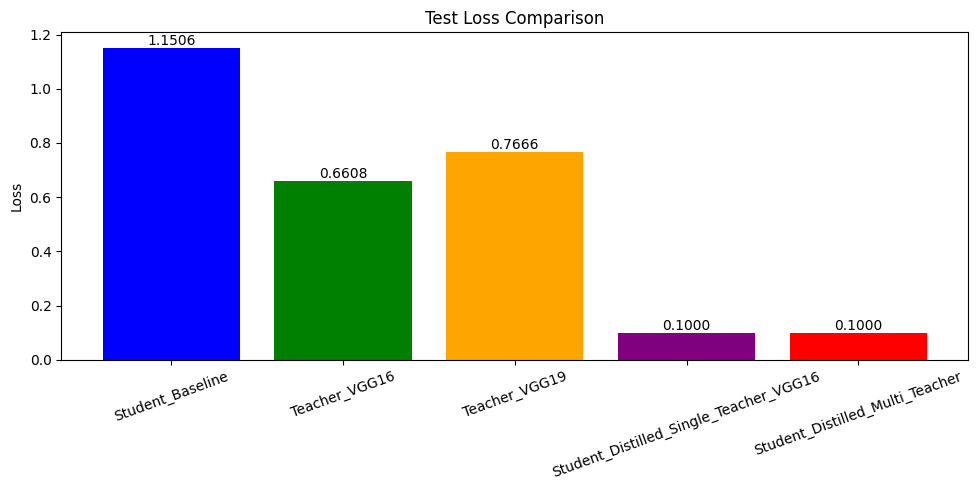

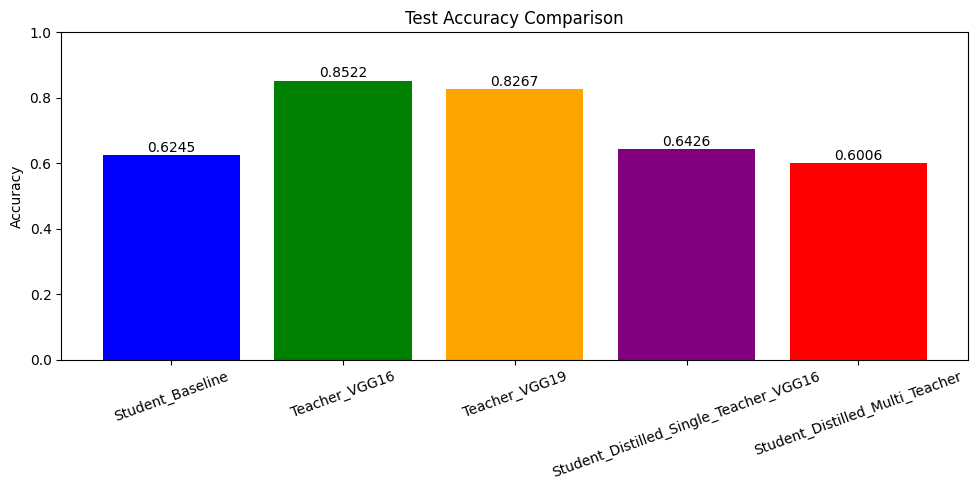

In [38]:
import matplotlib.pyplot as plt

# List of model names in desired order
model_names = [
    "Student_Baseline",
    "Teacher_VGG16",
    "Teacher_VGG19",
    "Student_Distilled_Single_Teacher_VGG16",
    "Student_Distilled_Multi_Teacher"
]

# Colors for each model (distinct)
colors = ['blue', 'green', 'orange', 'purple', 'red']

# Extract losses and accuracies
losses = [results[name]["Test Loss"] for name in model_names]
accuracies = [results[name]["Test Accuracy"] for name in model_names]

# Plot Test Loss
plt.figure(figsize=(10, 5))
bars1 = plt.bar(model_names, losses, color=colors)
plt.title('Test Loss Comparison')
plt.ylabel('Loss')
plt.xticks(rotation=20)
for i, bar in enumerate(bars1):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{losses[i]:.4f}", ha='center')
plt.tight_layout()
plt.show()

# Plot Test Accuracy
plt.figure(figsize=(10, 5))
bars2 = plt.bar(model_names, accuracies, color=colors)
plt.title('Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=20)
for i, bar in enumerate(bars2):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{accuracies[i]:.4f}", ha='center')
plt.tight_layout()
plt.show()
